Envelope shape: (512, 256)
Minimum: 2.9289706752050767e-06
Maximum: 1.3618068841963744


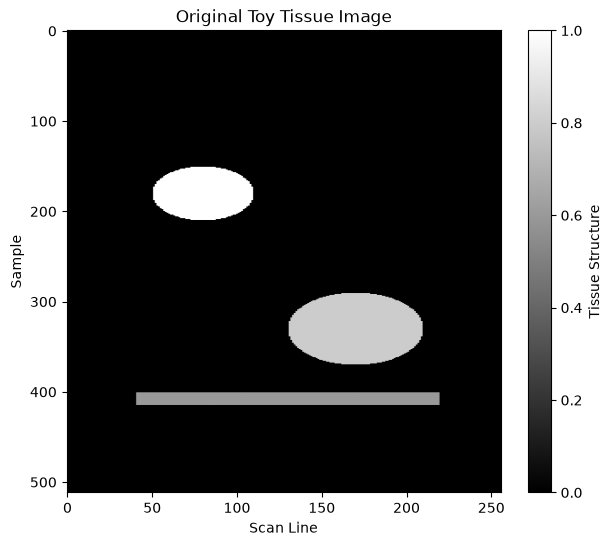

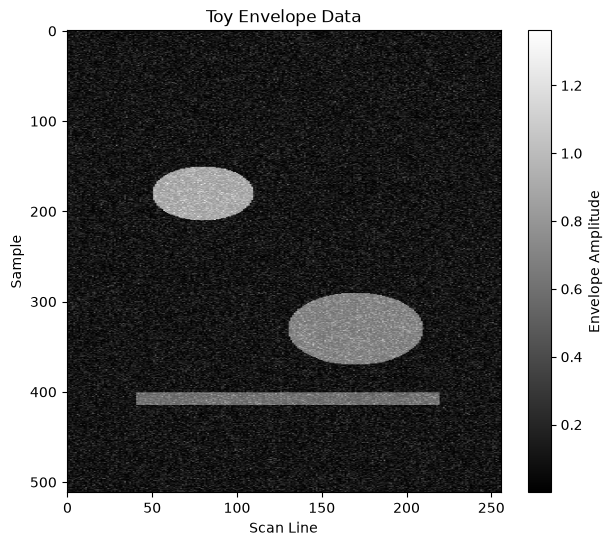

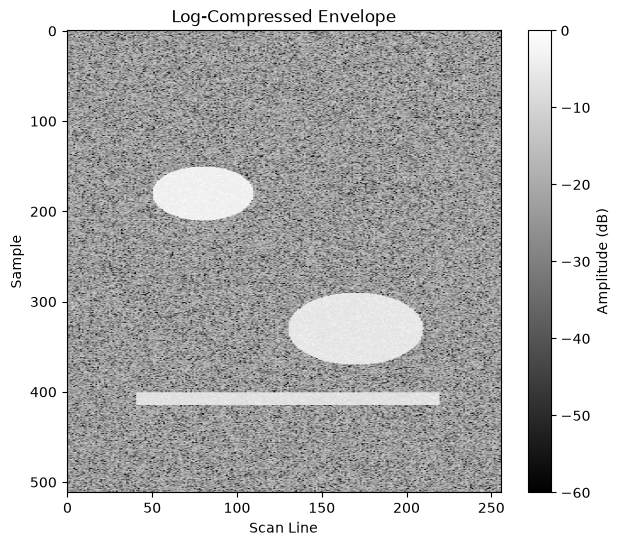

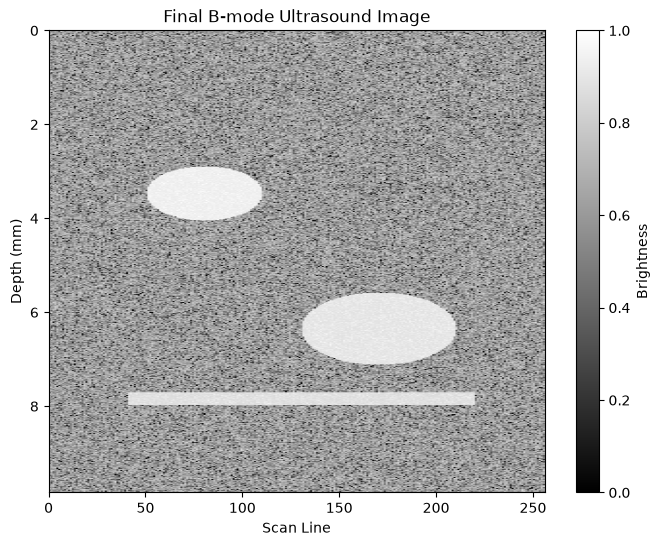

In [1]:
import numpy as np
import matplotlib.pyplot as plt



# 1. CREATE TOY IMAGE / TISSUE PHANTOM


np.random.seed(42)

num_samples = 512
num_scanlines = 256

y, x = np.ogrid[:num_samples, :num_scanlines]

# Start with a dark toy image
toy_image = np.zeros((num_samples, num_scanlines))

# Add circular structure 1
circle1 = (
    (y - 180)**2 +
    (x - 80)**2
) < 30**2

toy_image[circle1] = 1.0


# Add circular structure 2
circle2 = (
    (y - 330)**2 +
    (x - 170)**2
) < 40**2

toy_image[circle2] = 0.8


# Add horizontal structure
horizontal = (
    (y > 400) &
    (y < 415) &
    (x > 40) &
    (x < 220)
)

toy_image[horizontal] = 0.6



# 2. CREATE TOY ENVELOPE DATA


# Background speckle/noise
envelope = np.abs(
    np.random.randn(num_samples, num_scanlines)
) * 0.15

# Add echoes corresponding to toy structures

envelope[circle1] += 0.8

envelope[circle2] += 0.6

envelope[horizontal] += 0.5


# Make sure envelope is positive
envelope = np.maximum(envelope, 0)


print("Envelope shape:", envelope.shape)
print("Minimum:", envelope.min())
print("Maximum:", envelope.max())


# ==========================================
# 3. SAMPLING INFORMATION
# ==========================================

fs = 40e6       # Sampling frequency = 40 MHz
c = 1540        # Speed of sound = 1540 m/s

dynamic_range = 60   # 60 dB


# ==========================================
# 4. NORMALIZE ENVELOPE
# ==========================================

envelope_norm = envelope / np.max(envelope)


# ==========================================
# 5. CONVERT ENVELOPE TO dB
# ==========================================

envelope_db = 20 * np.log10(
    envelope_norm + 1e-12
)


# ==========================================
# 6. APPLY DYNAMIC RANGE
# ==========================================

envelope_db = np.clip(
    envelope_db,
    -dynamic_range,
    0
)


# ==========================================
# 7. CONVERT dB TO BRIGHTNESS
# ==========================================

bmode = (
    envelope_db + dynamic_range
) / dynamic_range


# ==========================================
# 8. CALCULATE DEPTH
# ==========================================

num_samples = envelope.shape[0]

sample_indices = np.arange(num_samples)

time = sample_indices / fs

depth = (c * time) / 2

depth_mm = depth * 1000


# ==========================================
# 9. DISPLAY TOY IMAGE
# ==========================================

plt.figure(figsize=(7, 6))

plt.imshow(
    toy_image,
    cmap="gray",
    aspect="auto"
)

plt.xlabel("Scan Line")
plt.ylabel("Sample")
plt.title("Original Toy Tissue Image")

plt.colorbar(label="Tissue Structure")

plt.show()


# ==========================================
# 10. DISPLAY ENVELOPE DATA
# ==========================================

plt.figure(figsize=(7, 6))

plt.imshow(
    envelope,
    cmap="gray",
    aspect="auto"
)

plt.xlabel("Scan Line")
plt.ylabel("Sample")
plt.title("Toy Envelope Data")

plt.colorbar(label="Envelope Amplitude")

plt.show()


# ==========================================
# 11. DISPLAY LOG-COMPRESSED ENVELOPE
# ==========================================

plt.figure(figsize=(7, 6))

plt.imshow(
    envelope_db,
    cmap="gray",
    aspect="auto",
    vmin=-dynamic_range,
    vmax=0
)

plt.xlabel("Scan Line")
plt.ylabel("Sample")
plt.title("Log-Compressed Envelope")

plt.colorbar(label="Amplitude (dB)")

plt.show()


# ==========================================
# 12. DISPLAY FINAL B-MODE
# ==========================================

num_scanlines = envelope.shape[1]

plt.figure(figsize=(8, 6))

plt.imshow(
    bmode,
    cmap="gray",
    aspect="auto",
    extent=[
        0,
        num_scanlines,
        depth_mm[-1],
        depth_mm[0]
    ]
)

plt.xlabel("Scan Line")
plt.ylabel("Depth (mm)")
plt.title("Final B-mode Ultrasound Image")

plt.colorbar(label="Brightness")

plt.show()